# Extracting features and embeddings of VocalMod VTE Dataset



## 1. Setup

In [1]:
import types, importlib, sys
imp = types.ModuleType("imp")
imp.reload = importlib.reload
sys.modules["imp"] = imp
%load_ext autoreload
%autoreload 2

In [2]:
import os 
import sys
import pandas as pd
from pathlib import Path

# Add parent directory to path so we can import scripts module
parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [3]:
from vocalSet_data_config import vocalset_dataset_config
from vocalset_extraction_config import vocalset_extraction
from scripts.validate_config import validate_configs

# Create dataset instance by calling the function
vocalset_dataset = vocalset_dataset_config()

print(f"Dataset: {vocalset_dataset.name}")
print(f"Root directory: {vocalset_dataset.root_dir}")
print(f"Levels: {vocalset_dataset.level_names}")

# View extraction configuration
print(f"\nExtractors: {vocalset_extraction.extractors}")
print(f"Output directory: {vocalset_extraction.output_dir}")
print(f"Window lengths: {vocalset_extraction.window_lengths}")

# Validate configurations
try:
    validate_configs(vocalset_dataset, vocalset_extraction)
    print("\n✓ Configurations are valid!")
except ValueError as e:
    print(f"\n✗ Configuration error: {e}")

Dataset: vocalset_dataset
Root directory: /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/FULL
Levels: ['singer', 'exercise_type', 'vocal_technique']

Extractors: ['clap', 'vggish']
Output directory: /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/
Window lengths: [3.0, 0.5]

✓ Configurations are valid!


## 2. Run Extractions

In [5]:
import logging
from scripts.run_extraction import run_extraction
from pathlib import Path

# Run extraction (this may take a while depending on dataset size)
log_file = "/home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/vocalset_extraction_run_log.jsonl"

# Pass file paths to run_extraction (not the config objects)
run_extraction(
    dataset_config_path="vocalSet_data_config.py",
    extraction_config_path="vocalset_extraction_config.py",
    log_file=log_file,
    console_output=False, # aim to reduce memory use of VSCode so the session doesnt crash
)

print(f"✓ Extraction complete! Logs saved to {log_file}")

✓ Extraction complete! Logs saved to /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/vocalset_extraction_run_log.jsonl


In [6]:
import logging
from scripts.run_extraction import run_extraction
from pathlib import Path

# Run extraction (this may take a while depending on dataset size)
log_file = "/home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/vocalset_extraction_run_log.jsonl"

# Pass file paths to run_extraction (not the config objects)
result = run_extraction(
    dataset_config_path="vocalSet_data_config.py",
    extraction_config_path="vocalset_extraction_config.py",
    log_file=log_file,
    console_output=True,  # Show output to debug what's happening
)

print(f"\n✓ Extraction complete! Logs saved to {log_file}")
print(f"\nExtraction summary:")
for key, value in result.items():
    print(f"  {key}: {value}")


{"timestamp": "2026-05-13T12:37:27.393738", "level": "INFO", "logger": "audio_extraction", "message": "Resolved batch_size: 100 files", "stage": "initialization"}
{"timestamp": "2026-05-13T12:37:27.394473", "level": "INFO", "logger": "audio_extraction", "message": "Extraction pipeline starting", "stage": "initialization"}
{"timestamp": "2026-05-13T12:37:27.394887", "level": "INFO", "logger": "audio_extraction", "message": "Starting extraction: clap @ 3.0s for vocalset_dataset", "stage": "extraction_start", "extractor": "clap", "window_length": 3.0}
{"timestamp": "2026-05-13T12:37:27.395618", "level": "ERROR", "logger": "audio_extraction", "message": "Failed to instantiate extractor clap: No module named 'msclap'", "stage": "extractor_instantiation_error", "extractor": "clap"}
{"timestamp": "2026-05-13T12:37:27.395916", "level": "INFO", "logger": "audio_extraction", "message": "Starting extraction: vggish @ 3.0s for vocalset_dataset", "stage": "extraction_start", "extractor": "vggish", 

In [ ]:

# Check the logs to see what happened during extraction
import json
from pathlib import Path

log_file = Path("/home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/vocalset_extraction_run_log.jsonl")

print(f"Log file: {log_file}")
print(f"File exists: {log_file.exists()}")
print(f"File size: {log_file.stat().st_size if log_file.exists() else 'N/A'} bytes")

if log_file.exists():
    print("\n--- Last 20 log entries ---")
    with open(log_file) as f:
        lines = f.readlines()
        for line in lines[-20:]:
            entry = json.loads(line.strip())
            stage = entry.get("stage", "?")
            level = entry.get("level", "?")
            message = entry.get("message", "")[:80]  # First 80 chars
            print(f"[{level:5s}] {stage:25s} | {message}")


In [ ]:

# First, check what output files already exist
from pathlib import Path
output_dir = Path("/home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/")

print("Existing parquet files:")
for f in sorted(output_dir.glob("*.parquet")):
    size_mb = f.stat().st_size / (1024*1024)
    print(f"  - {f.name:60s} ({size_mb:.1f} MB)")

print("\nExisting checkpoint files:")
checkpoints = list(output_dir.glob("*.checkpoint.jsonl"))
if checkpoints:
    for cp in sorted(checkpoints):
        print(f"  - {cp.name}")
else:
    print("  (none - these get cleaned up after successful extraction)")

print("\nExisting HDF5 files:")
h5_files = list(output_dir.glob("*.h5"))
if h5_files:
    for h5 in sorted(h5_files):
        print(f"  - {h5.name}")
else:
    print("  (none - these get cleaned up after successful extraction)")


## 3. Explore results

In [16]:
from scripts.utils import load_parquet  
# Load extraction results

output_dir = Path(vocalset_extraction.output_dir)

# List all output files
output_files = list(output_dir.glob("*.parquet"))
print("Generated output files:")
for f in output_files:
    print(f"  - {f.name}")

Generated output files:
  - vocalset_dataset_whisper_whisper-base_0.5s.parquet
  - vocalset_dataset_whisper_whisper-base_3.0s.parquet
  - vocalset_dataset_opensmile-compare-2016_3.0s.parquet
  - vocalset_dataset_opensmile-compare-2016_0.5s.parquet


In [12]:
df_opensmile = load_parquet(
    os.path.join(output_dir, "vocalset_dataset_opensmile-compare-2016_3.0s.parquet")
)

print(f"\nVGGish embeddings shape: {df_opensmile.shape}")
print(f"Columns: {list(df_opensmile.columns)}")
print(f"\nFirst few rows:")
df_opensmile.head()


VGGish embeddings shape: (10546, 10)
Columns: ['exercise_type', 'extractor', 'filename', 'filepath', 'frame_index', 'singer', 'vocal_technique', 'embedding', 'embedding_dtype', 'embedding_shape']

First few rows:


,exercise_type,extractor,filename,filepath,frame_index,singer,vocal_technique,embedding,embedding_dtype,embedding_shape
0,arpeggios,opensmile-compare-2016,f1_arpeggios_belt_c_a,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[2.1086946, 0.97269624, 0.0, 0.6850486, 0.8989...",<f4,[6373]
1,arpeggios,opensmile-compare-2016,f1_arpeggios_belt_c_a,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,1,female1,belt,"[1.5428679, 0.3208191, 0.9897611, 0.8161966, 1...",<f4,[6373]
2,arpeggios,opensmile-compare-2016,f1_arpeggios_belt_c_e,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[1.6066055, 0.97952217, 0.0, 0.5867397, 0.9134...",<f4,[6373]
3,arpeggios,opensmile-compare-2016,f1_arpeggios_belt_c_e,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,1,female1,belt,"[0.86089426, 0.25938568, 0.6450512, 0.83925277...",<f4,[6373]
4,arpeggios,opensmile-compare-2016,f1_arpeggios_belt_c_i,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[1.7399231, 0.97952217, 0.0, 0.31953323, 0.554...",<f4,[6373]


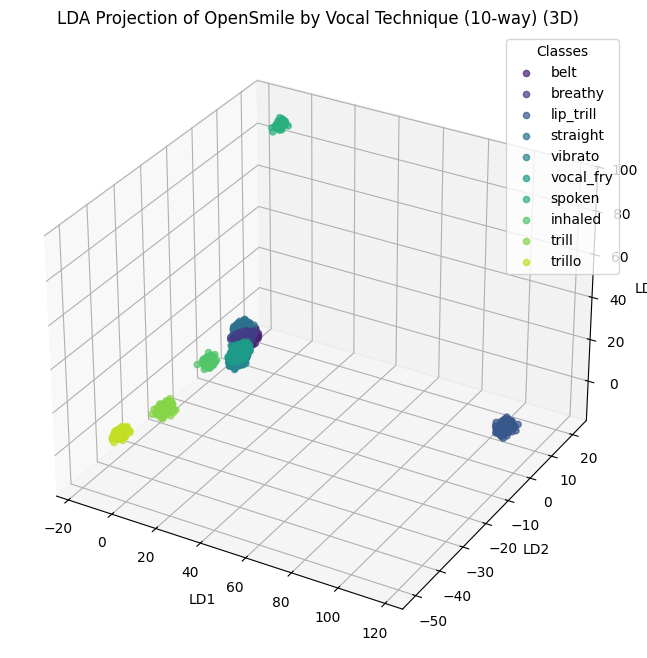

In [18]:
from scripts.feature_visualisation import prepare_and_plot_lda

prepare_and_plot_lda(
    df_opensmile,
    class_col="vocal_technique",
    mode="3d",
    data_type="OpenSmile by Vocal Technique (10-way)",
    filters={
        "vocal_technique": [
            "vibrato",
            "straight",
            "trill",
            "trillo",
            "belt",
            "breathy",
            "inhaled",
            "spoken",
            "vocal_fry",
            "lip_trill"
        ]
    },
)

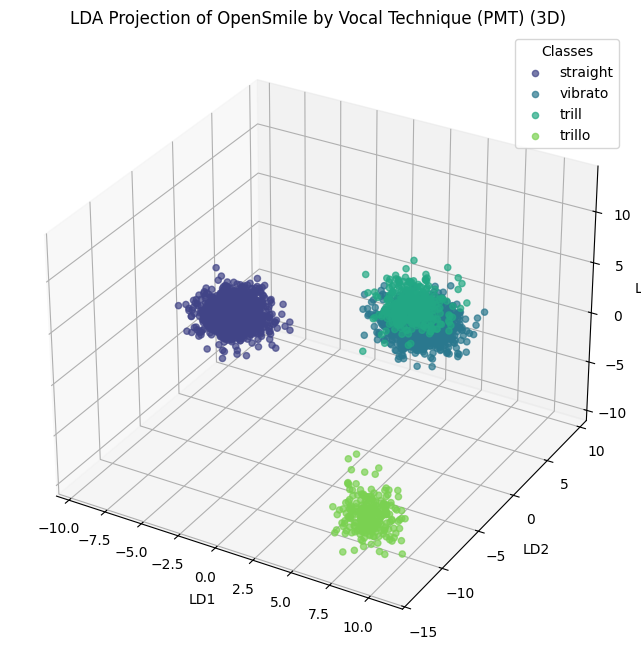

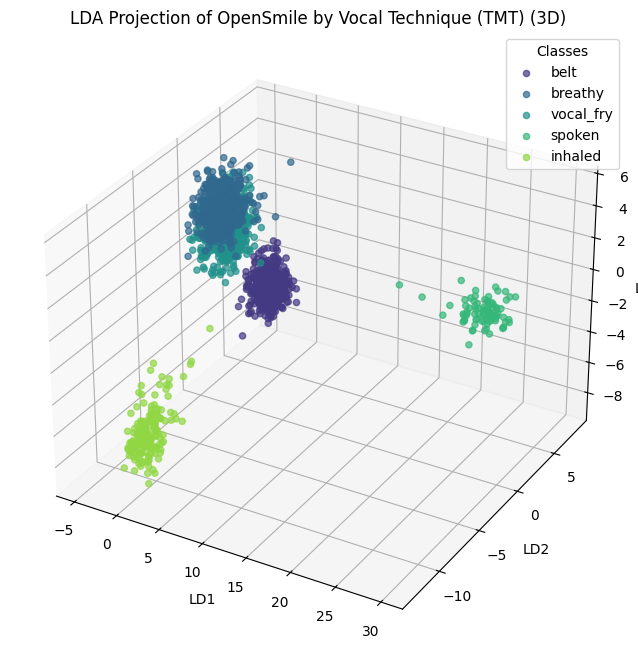

In [15]:
prepare_and_plot_lda(
    df_opensmile,
    class_col="vocal_technique",
    mode="3d",
    data_type="OpenSmile by Vocal Technique (PMT)",
    filters={"vocal_technique": ["vibrato", "straight", "trill", "trillo"]},
)

prepare_and_plot_lda(
    df_opensmile,
    class_col="vocal_technique",
    mode="3d",
    data_type="OpenSmile by Vocal Technique (TMT)",
    filters={"vocal_technique": ["belt", "breathy", "inhaled", "spoken", "vocal_fry"]},
)

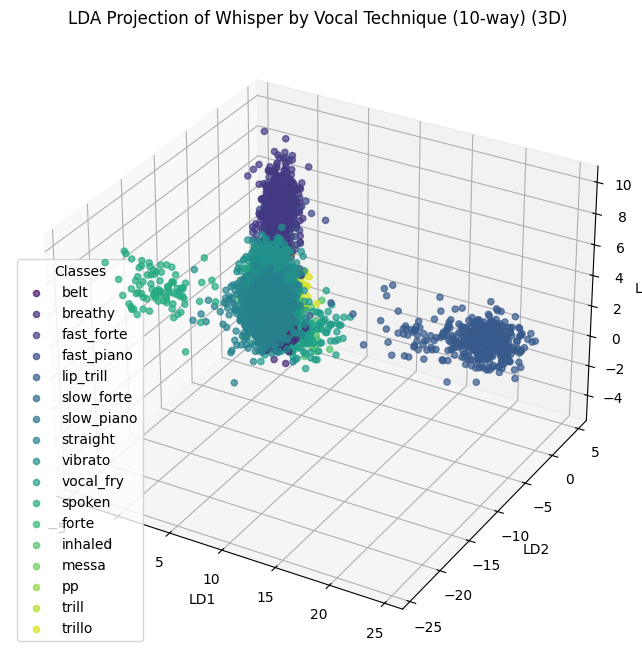

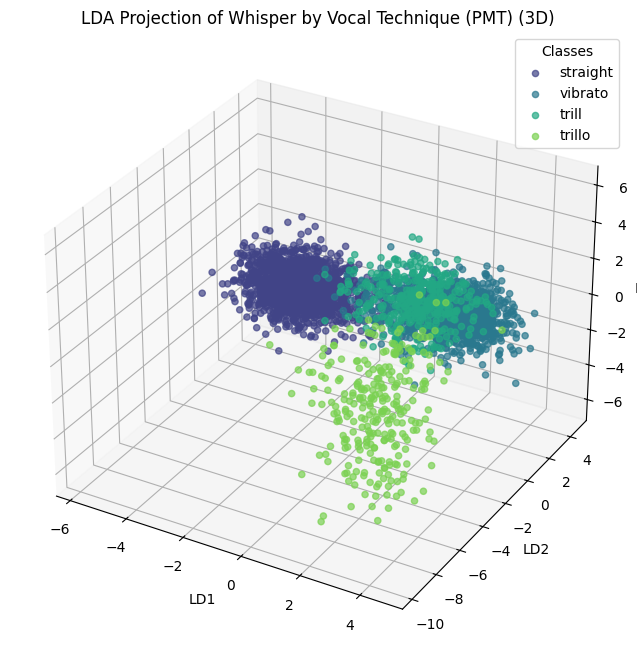

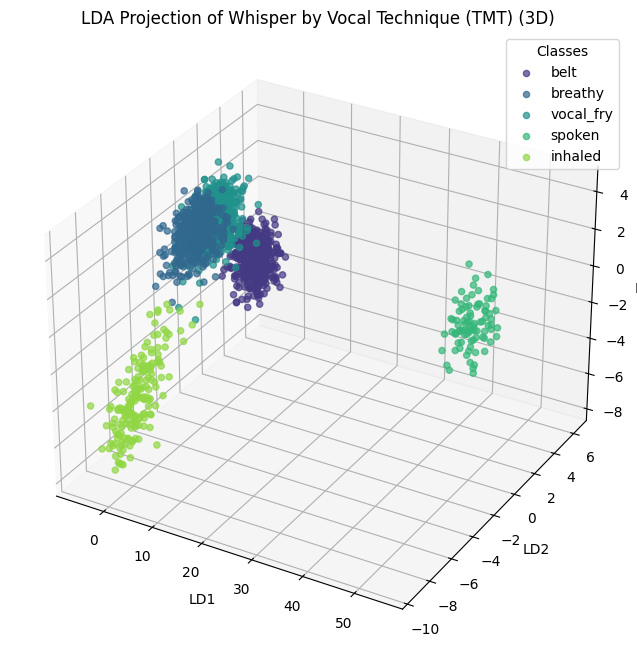

In [19]:
df_whisper = load_parquet(
    os.path.join(output_dir, "vocalset_dataset_whisper_whisper-base_3.0s.parquet")
)

prepare_and_plot_lda(
    df_whisper,
    class_col="vocal_technique",
    mode="3d",
    data_type="Whisper by Vocal Technique (10-way)",
)

prepare_and_plot_lda(
    df_whisper,
    class_col="vocal_technique",
    mode="3d",
    data_type="Whisper by Vocal Technique (PMT)",
    filters={"vocal_technique": ["vibrato", "straight", "trill", "trillo"]},
)

prepare_and_plot_lda(
    df_whisper,
    class_col="vocal_technique",
    mode="3d",
    data_type="Whisper by Vocal Technique (TMT)",
    filters={"vocal_technique": ["belt", "breathy", "inhaled", "spoken", "vocal_fry"]},
)